# Classifing Quasar over Galaxies

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
df_gq = pd.read_csv("galaxyquasar.csv")
df_gq

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [3]:
ug = df_gq.get("u") - df_gq.get("g")
gr = df_gq.get("g") - df_gq.get("r")
ri = df_gq.get("r") - df_gq.get("i")
iz = df_gq.get("i") - df_gq.get("z")
class_list = []
for i in range(len(df_gq)):
    if df_gq.get("class")[i] == "GALAXY":
        class_list.append(0)
    else:
        class_list.append(1)

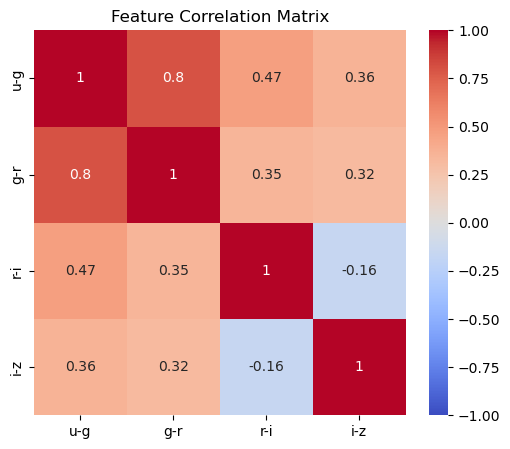

In [22]:
import seaborn as sns

df = pd.DataFrame({
    "u-g": ug,
    "g-r": gr,
    "r-i": ri,
    "i-z": iz,
})
corr_matrix = df.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.show()

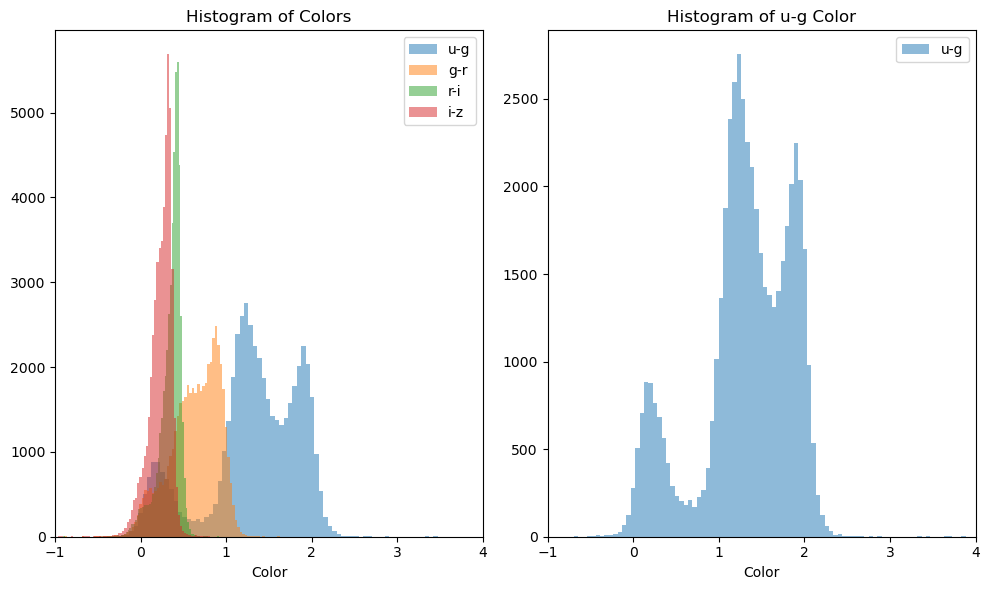

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))

ax[0].hist(ug, bins="scott", alpha=0.5, label='u-g', color='C0')
ax[0].hist(gr, bins="scott", alpha=0.5, label='g-r', color='C1')
ax[0].hist(ri, bins="scott", alpha=0.5, label='r-i', color='C2')
ax[0].hist(iz, bins="scott", alpha=0.5, label='i-z', color='C3')
ax[0].set_xlabel("Color")
ax[0].set_title("Histogram of Colors")
ax[0].set_xlim(-1, 4)
ax[0].legend()


ax[1].hist(ug, bins="scott", alpha=0.5, label='u-g', color='C0')
ax[1].set_xlabel("Color")
ax[1].set_title("Histogram of u-g Color")
ax[1].set_xlim(-1, 4)
ax[1].legend()

plt.tight_layout()
plt.show()

### Cross validation in KNN

We need to tune the hyperparameter for KNearestNeighbor classifier. 

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import  confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(ug, class_list, test_size=0.2, random_state=42)

In [8]:
gscv = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9]},
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

X = np.array(X_train).reshape(-1, 1)
Y = np.array(Y_train)

gscv.fit(X, Y)
gscv.best_params_, gscv.best_score_

({'n_neighbors': 9}, 0.9752353451942717)

In [9]:
knc = KNeighborsClassifier(n_neighbors=gscv.best_params_['n_neighbors'])

knc.fit(X, Y)

KNeighborsClassifier(n_neighbors=9)

In [10]:
from sklearn.metrics import confusion_matrix

X = np.array(X_test).reshape(-1, 1)
Y = np.array(Y_test)


Y_pred = knc.predict(X)
cm = confusion_matrix(Y, Y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[8484   88]
 [ 116 1312]]


### ROC curve for different classifier

In [11]:
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

In [12]:
from sklearn.model_selection import train_test_split

X = np.array(ug).reshape(-1, 1)
Y = class_list

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [13]:
labels = ["GNB", "LDA", "QDA", "KNN"]
models = [GaussianNB(), LinearDiscriminantAnalysis(), QuadraticDiscriminantAnalysis(), KNeighborsClassifier(9)]

for model in models:
    model.fit(X_train, y_train)

In [14]:
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score

linestyle = ['-', '--', '-.', ':']

roc_data = {}
pr_data = {}

for label, model in zip(labels, models):
    y_score = model.predict_proba(X_test)[:, 1]
    roc_data[label] = roc_curve(y_test, y_score)
    pr_data[label] = precision_recall_curve(y_test, y_score)

In [15]:
pd.DataFrame(roc_data)

,GNB,LDA,QDA,KNN
0,"[0.0, 0.00011619800139437602, 0.00058099000697...","[0.0, 0.00011619800139437602, 0.00058099000697...","[0.0, 0.00011619800139437602, 0.00058099000697...","[0.0, 0.0020915640250987683, 0.003253544039042..."
1,"[0.0, 0.0, 0.0, 0.002152080344332855, 0.002152...","[0.0, 0.0, 0.0, 0.002152080344332855, 0.002152...","[0.0, 0.0, 0.0, 0.002152080344332855, 0.002152...","[0.0, 0.6836441893830703, 0.8407460545193687, ..."
2,"[inf, 0.9999999992729798, 0.9999057209127973, ...","[inf, 0.9999999999999083, 0.999953619735856, 0...","[inf, 0.9999999992766375, 0.9999057159380752, ...","[inf, 1.0, 0.8888888888888888, 0.7777777777777..."


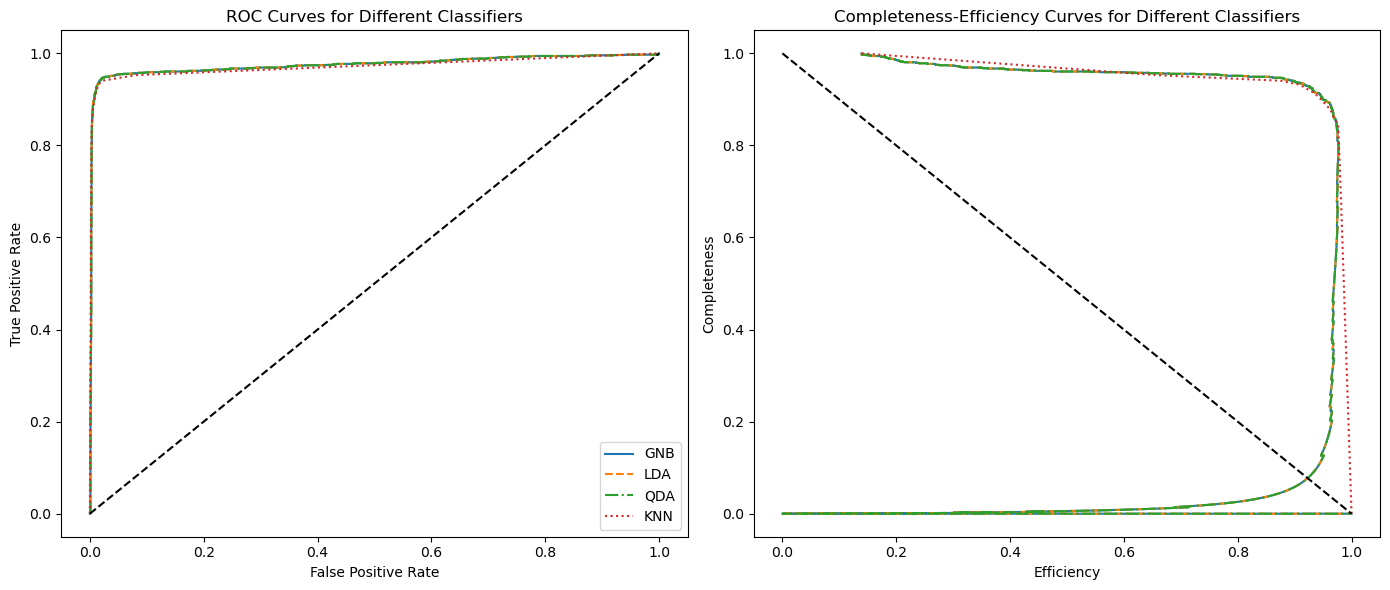

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

for label, (fpr, tpr, threshold) in roc_data.items():
    fpr, tpr, _ = roc_data[label]
    axs[0].plot(fpr, tpr, label=label, linestyle=linestyle[list(roc_data.keys()).index(label)])
axs[0].plot([0, 1], [0, 1], 'k--')
axs[0].set_xlabel('False Positive Rate')
axs[0].set_ylabel('True Positive Rate')
axs[0].set_title('ROC Curves for Different Classifiers')
axs[0].legend()

for label, (precision, recall, threshold) in pr_data.items():
    precision, recall, _ = pr_data[label]
    axs[1].plot(precision, recall, label=label, linestyle=linestyle[list(pr_data.keys()).index(label)])
axs[1].plot([0, 1], [1, 0], 'k--')
axs[1].set_xlabel('Efficiency')
axs[1].set_ylabel('Completeness')
axs[1].set_title('Completeness-Efficiency Curves for Different Classifiers')

plt.tight_layout()

Curves overlap and seems that the dataset is very easy to be classified. All the algorithm can distinguish very well Galaxies from Quasars.

### Including more features

Let's see how the classifier react adding more colors.

In [17]:
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import roc_curve, precision_recall_curve

In [18]:
def check_rutine(models, labels, X, Y, split_size):

    roc_data = {}
    pr_data = {}

    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=split_size)
    
    for label, model in zip(labels, models):
        model.fit(X_train, y_train)
        y_score = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_score)
        precision, recall, _ = precision_recall_curve(y_test, y_score)
        roc_data[label] = (fpr, tpr)
        pr_data[label] = (precision, recall)
    
    return roc_data, pr_data

def plot_rutine(roc_data, pr_data, linestyle):
    fig,axs = plt.subplots(1, 2, figsize=(14, 6))

    for label, (fpr, tpr) in roc_data.items():
        axs[0].plot(fpr, tpr, label=label, linestyle=linestyle[list(roc_data.keys()).index(label)])
    axs[0].plot([0, 1], [0, 1], 'k--')
    axs[0].set_xlabel('False Positive Rate')
    axs[0].set_ylabel('True Positive Rate')
    axs[0].set_title('ROC Curves for Different Classifiers')
    axs[0].legend()

    for label, (precision, recall) in pr_data.items():
        axs[1].plot(precision, recall, label=label, linestyle=linestyle[list(pr_data.keys()).index(label)])
    axs[1].plot([0, 1], [1, 0], 'k--')
    axs[1].set_xlabel('Efficiency')
    axs[1].set_ylabel('Completeness')
    axs[1].set_title('Contamination-Efficiency Curves for Different Classifiers')



In [19]:
models = [GaussianNB(), LinearDiscriminantAnalysis(), QuadraticDiscriminantAnalysis(), KNeighborsClassifier(9)]
labels = ["GNB", "LDA", "QDA", "KNN"]
linestyle = ['-', '--', '-.', ':']

split_size = 0.2

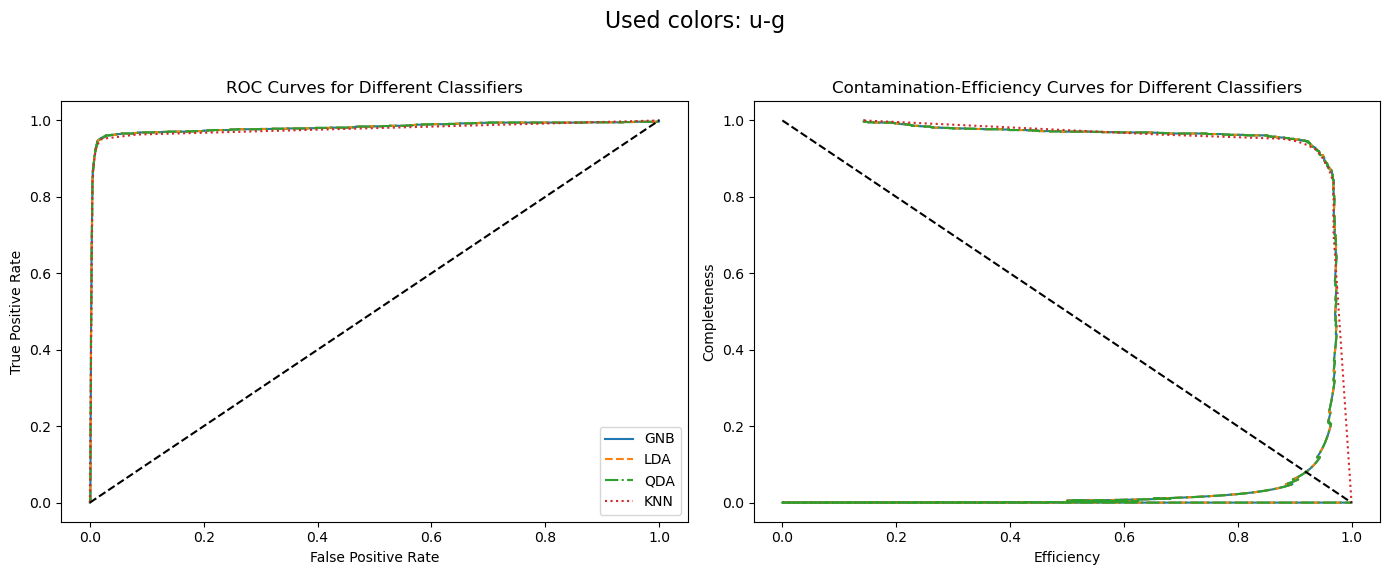

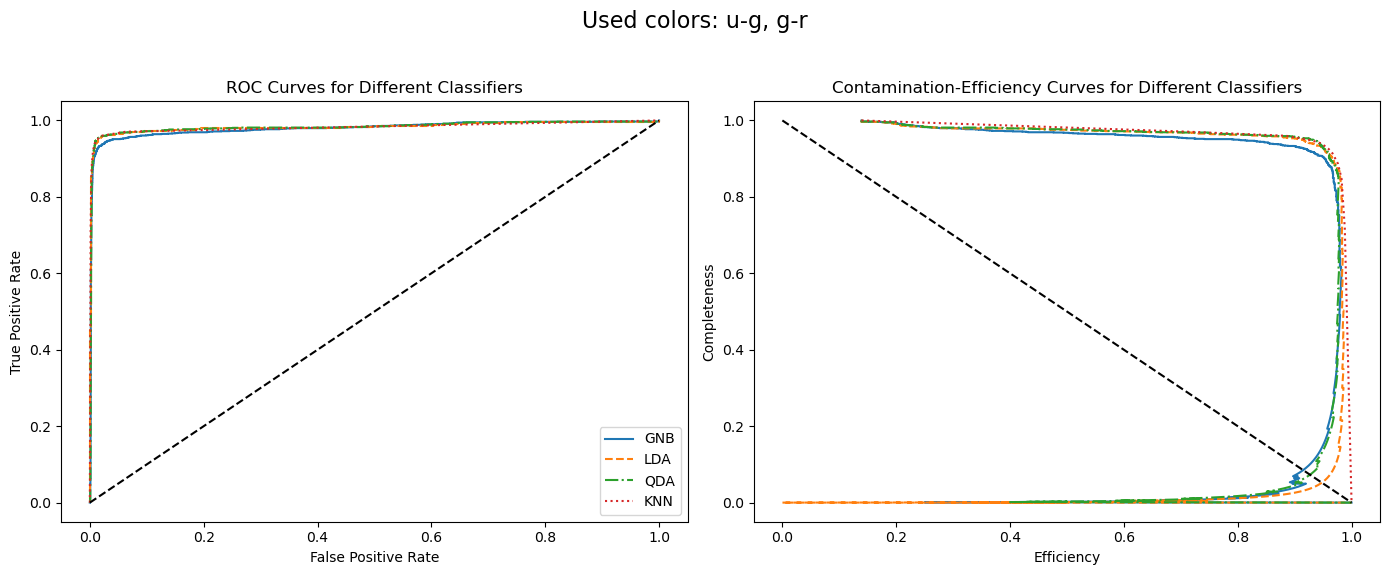

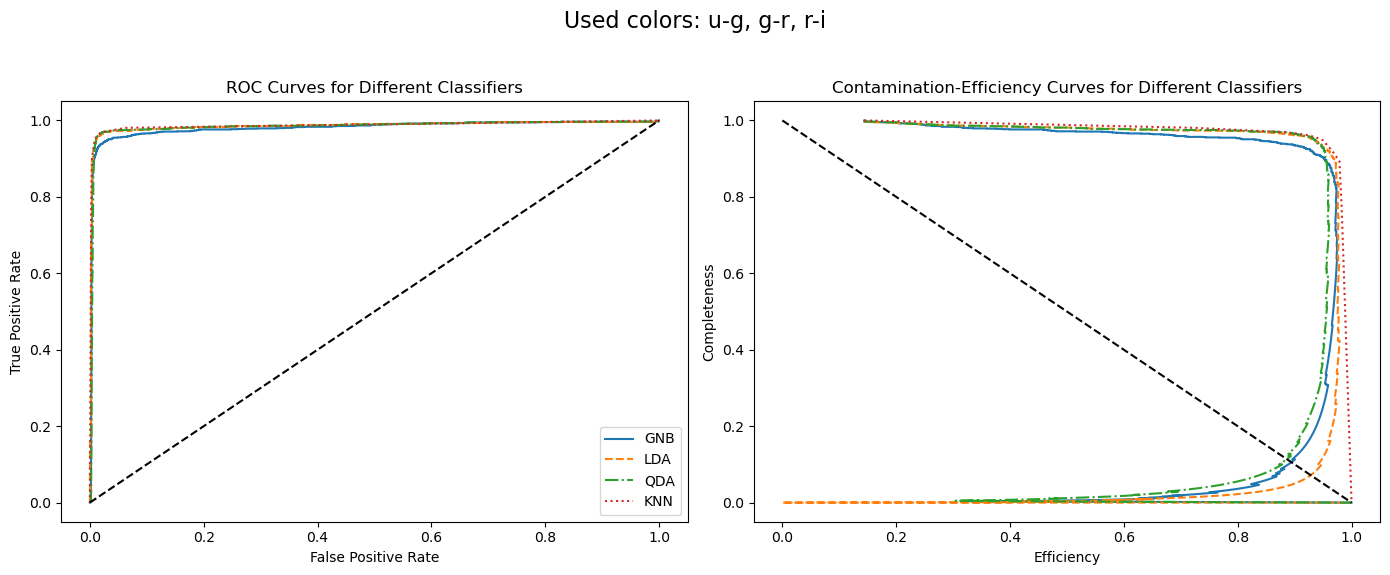

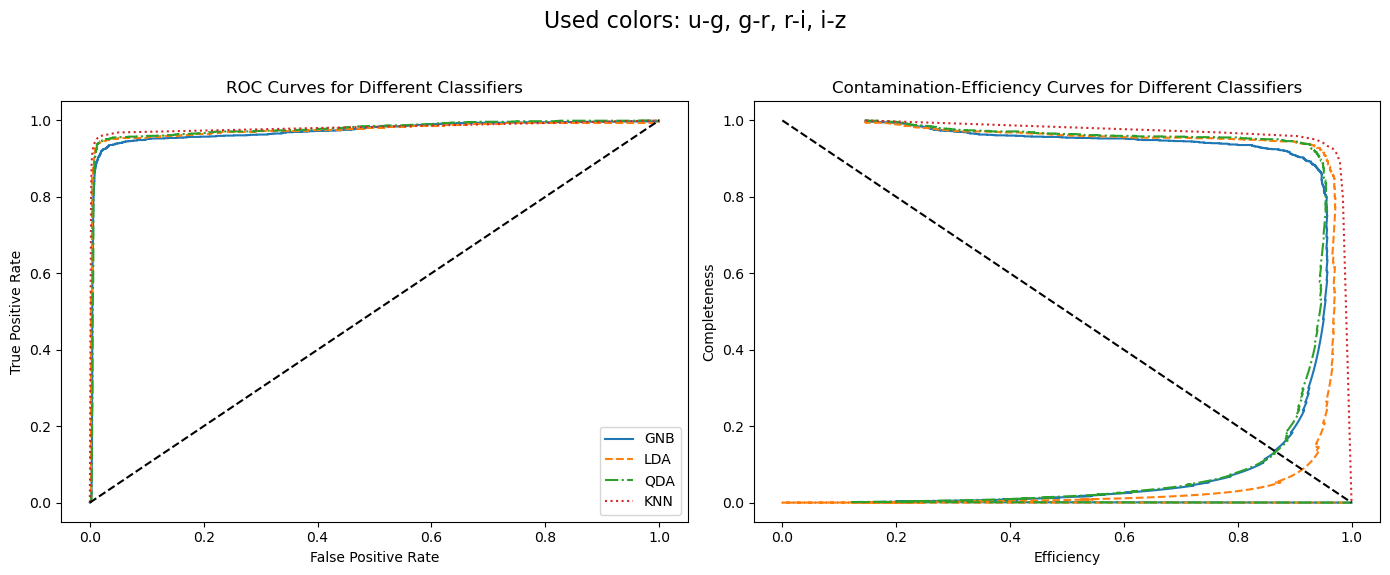

In [20]:
colors = [ug, gr, ri, iz]
color_names = ["u-g", "g-r", "r-i", "i-z"]
n_features = len(colors)

completeness = {label: [] for label in labels}
contamination = {label: [] for label in labels}

for i in range(n_features):
    X = np.column_stack(colors[:i+1])
    Y = class_list

    roc_data, pr_data = check_rutine(models, labels, X, Y, split_size)

    for label, (precision, recall) in pr_data.items():
        idx_target = np.argmax(precision >= 0.9) 
        completeness[label].append(recall[idx_target])
        contamination[label].append(1 - precision[idx_target])

    plot_rutine(roc_data, pr_data, linestyle)
    added_colors = ", ".join(color_names[:i+1])
    plt.suptitle(f'Used colors: {added_colors}', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()


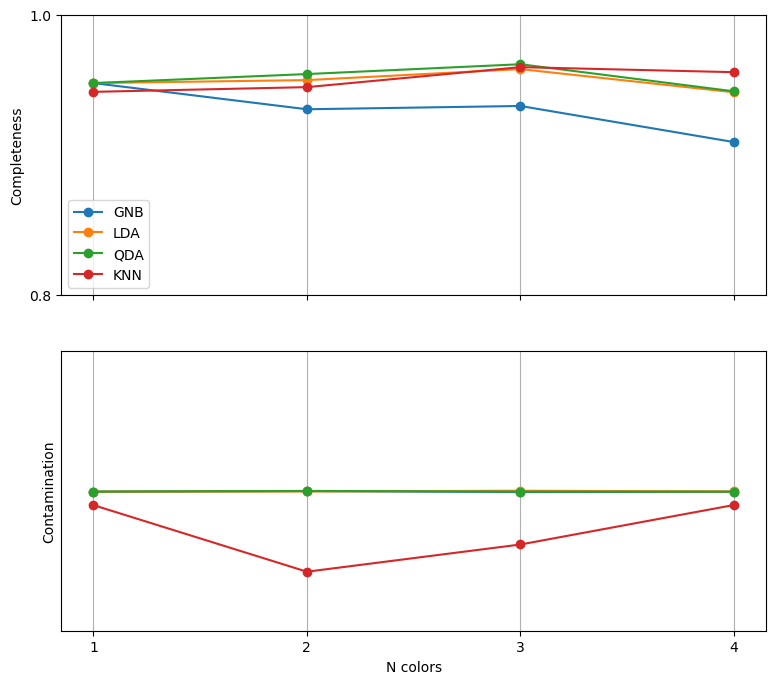

In [21]:
x_features = np.arange(1, n_features + 1)

plt.figure(figsize=(20, 8))
ax = plt.subplot(222)
for label in labels:
    ax.plot(x_features, completeness[label], 'o-', ms=6, label=label)

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.NullFormatter())
ax.set_ylabel('Completeness')
ax.set_ylim(0.8, 1)
ax.grid(True)
ax.legend(loc='best') 

ax2 = plt.subplot(224)
for label in labels:
    ax2.plot(x_features, contamination[label], 'o-', label=label)

ax2.xaxis.set_major_locator(plt.MultipleLocator(1))
ax2.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax2.xaxis.set_major_formatter(plt.FormatStrFormatter('%i'))
ax2.set_xlabel('N colors')
ax2.set_ylabel('Contamination')
ax2.set_ylim(0.05, 0.15)
ax2.grid(True)

plt.show()

KNN gives the best overall results: it reaches high completeness, which steadily improves as more color features are added, while keeping contamination low and similar to QDA. GNB performs the worst in terms of completeness. The fact that only KNN clearly benefits from adding more features suggests that it is better at capturing the information contained in the correlations (and possible non-linear relationships) between the colors, whereas the Gaussian-based classifiers do not seem to take the same advantage from the extra features.